In [1]:
import pandas as pd
import geopandas as gpd
import rioxarray
from shapely.geometry import box, Point
import cv2
import matplotlib.pyplot as plt
from georefcam.camera_model import CTCameraModel
from georefcam.dem import RasterioDEM
from georefcam.georefcam import GeoRefCam, get_direction_vector
import numpy as np
import pyvista as pv
import rioxarray
from PIL import Image
import glob
import os
from sklearn.metrics import mean_squared_error
from dem_utils import compute_dem_bbox_from_point, download_dem_eio, reproject_and_save_dem

In [2]:
sites_data = pd.read_csv("data/sites.csv")
sites_data

,name,lat,lon,elevation,fov_x,fov_y
0,brison,44.545155,4.216534,830,87,44
1,marguerite,44.688492,4.313501,984,87,44
2,cabanelle,43.786647,7.419608,1080,87,44
3,courmettes,43.715592,7.026486,800,87,44
4,valbonne,43.623364,7.027940,200,87,44
5,croix-augas,48.426746,2.710876,150,54,44


In [3]:
images = glob.glob("data/images/*")
images.sort()
img_file = images[5]
site, azimuth = os.path.basename(img_file).split('_')[1].split('-')
site, azimuth

('brison', '200')

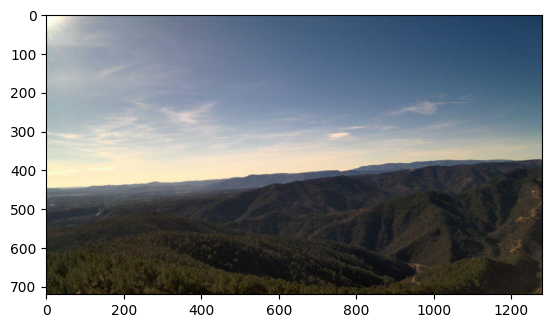

In [4]:
im = cv2.imread(img_file)
plt.imshow(im[:,:,::-1])

In [5]:
site_data = sites_data[sites_data["name"]==site]
site_data

,name,lat,lon,elevation,fov_x,fov_y
0,brison,44.545155,4.216534,830,87,44


In [6]:
lat = float(site_data["lat"])
lon = float(site_data["lon"])
pitch, roll = 0, 0
elevation = int(site_data["elevation"])  # Elevation + tour size 
fov_x = int(site_data["fov_x"])
fov_y = int(site_data["fov_y"])
lat, lon, elevation

(44.5451545715, 4.2165341377, 830)

In [7]:
azimuth = 217
pitch = -3

In [8]:
bbox = compute_dem_bbox_from_point(lat, lon)
download_dem_eio(bbox)
reproject_and_save_dem("srtm_dem.tif", "srtm_dem_l93.tif")


Running: eio --product SRTM1 clip --bounds 3.7673764956402387 44.22416079256764 4.665691779759761 44.86438805459089 --output srtm_dem.tif
✅ DEM downloaded: srtm_dem.tif
✅ Reprojected DEM saved to srtm_dem_l93.tif


In [9]:
# === Load Camera Metadata ===
cam_name = f"{site}-{azimuth}"
cam_info = pd.Series({
    "login": cam_name,
    "lat": lat,
    "lon": lon,
    "geometry": Point(lon, lat),
    "azimuth" : float(azimuth),
    "pitch" : pitch,
    "elevation" : elevation,
    "roll" : roll
})

# Create a GeoSeries with correct CRS
gdf_cams = gpd.GeoDataFrame([cam_info], geometry="geometry", crs="EPSG:4326")


# === Load Test Image ===
test_img = Image.open(img_file)
test_img_res = test_img.size



In [10]:
# === Prepare DEM ===
dem_data = rioxarray.open_rasterio("srtm_dem_l93.tif", masked=True).squeeze()
if dem_data.rio.crs != "EPSG:2154":
    dem_data = dem_data.rio.reproject("EPSG:2154")
dem_path = "dem_l93.tif"
dem_data.rio.to_raster(dem_path)

dem = RasterioDEM(dem_path, crs="EPSG:2154")
dem.build_pcd(sample_step=10)
dem.build_mesh(method='trimesh')



In [11]:
# === Create Camera Model ===
cam_model = CTCameraModel(
    test_img_res,
    fov_x, fov_y,  # FoV x, y
    cam_info.azimuth,
    cam_info.pitch,
    cam_info.roll,  # roll
    cam_info.lat,
    cam_info.lon,
    cam_info.elevation,
)
# Manual overrides


geocam = GeoRefCam(cam_model, dem)


In [12]:


cam_dirvec = get_direction_vector(geocam.camera_model.yaw_deg, geocam.camera_model.pitch_deg)

# Reproject camera location if needed
if geocam.camera_model.cam_loc[3] != geocam.dem.crs:
    cam_loc = geocam.project_points_from_cam_to_dem_crs(
        np.array([geocam.camera_model.cam_loc[:3]])
    )[0]
else:
    cam_loc = geocam.camera_model.cam_loc[:3]


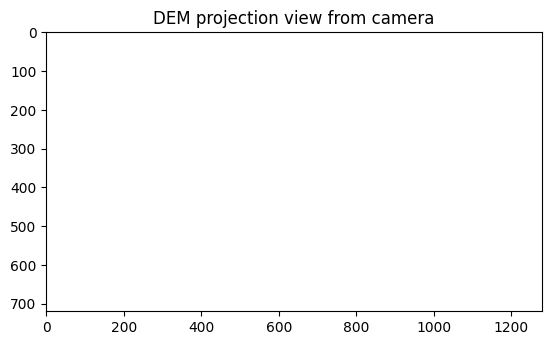

In [13]:
# Setup PyVista camera
pv_camera = pv.Camera()
pv_camera.position = cam_loc
pv_camera.focal_point = cam_loc + cam_dirvec
pv_camera.view_angle = geocam.camera_model.view_y_deg
pv_camera.clipping_range = (30, 1e5)
pv_camera.up = (0, 0, 1)

# Create plot
plotter = pv.Plotter(off_screen=True, window_size=test_img.size)
plotter.camera = pv_camera

plot_pv_meshgrid = pv.StructuredGrid(*[geocam.dem.pcd[:, :, i] for i in range(3)])
plot_pv_meshgrid["alt"] = geocam.dem.pcd[:, :, 2].ravel(order="F")
plotter.add_mesh(plot_pv_meshgrid, lighting=False)
plotter.remove_scalar_bar()

plotter.screenshot()
dem_depth = -1 * plotter.get_image_depth()



# === Display Result ===
plt.imshow(dem_depth, cmap='gray')
plt.title("DEM projection view from camera")

plt.show()


In [14]:
def extract_horizon_from_image(image_path: str) -> np.ndarray:
    img = cv2.imread(image_path)  # BGR format
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    edges = cv2.Canny(gray, threshold1=50, threshold2=150)
    flipped_edges = edges[::-1, :]
    horizon_indices = np.argmax(flipped_edges > 0, axis=0)
    horizon = gray.shape[0] - 1 - horizon_indices
    return horizon

def extract_horizon_profile(geocam, width=1280):
    yaw = geocam.camera_model.yaw_deg
    pitch = geocam.camera_model.pitch_deg
    fov_x = geocam.camera_model.view_x_deg

    # 1. Génére les angles dans le champ horizontal
    angles = np.linspace(yaw - fov_x / 2, yaw + fov_x / 2, width)
    print("pitch =", pitch)
    print("angles[0:5] =", angles[:5])


    # 2. Origines (position caméra)
    origin = geocam.camera_model.cam_loc[:3]
    if not np.all(np.isfinite(origin)):
        raise ValueError(f"Non-finite cam origin: {origin}")

    origins = np.tile(origin, (width, 1))

    # 3. Directions
    directions = []
    for az in angles:
        vec = get_direction_vector(az, pitch, length=10000)
        if not np.all(np.isfinite(vec)):
            print(f"[ERROR] get_direction_vector({az}, {pitch}) = {vec}")
            raise ValueError("Invalid direction vector (NaN or inf)")
        directions.append(vec)

    directions = np.array(directions)


    # 4. Targets
    targets = origins + directions
    if not np.all(np.isfinite(targets)):
        raise ValueError("Non-finite values in targets")
    
    print("[DEBUG] Sample targets:", targets[:5])
    print("[DEBUG] Norm of directions:", np.linalg.norm(directions, axis=1).max())


    # 5. Stack en rayons
    rays = np.stack([origins, targets], axis=2)

 
    # 6. Check final rays
    if not np.all(np.isfinite(rays)):
        bad = np.where(~np.isfinite(rays))
        raise ValueError(f"Non-finite rays at indices {bad}")
    
   
    # 7. Cast rays
    intersections = geocam.cast_rays(rays)
    return intersections[:, 2]  # Z = altitude






In [15]:
fixed_pitch = -3
height, width = dem_depth.shape
height, width

(720, 1280)

In [16]:
img = cv2.imread(img_file)
img.shape

(720, 1280, 3)

In [17]:
AZIMUTH_STEP = 15  # Large pas pour première passe
REFINEMENT_STEP = 1
FOV_X = 54.2

extracted_horizon = extract_horizon_from_image(img_file)
width = extracted_horizon.shape[0]


# Première passe
coarse_profiles = {}
for az in range(0, 360, AZIMUTH_STEP):
    cam_model = CTCameraModel(
        (width, height),  # ✅ attention à l’ordre
        FOV_X,
        fov_y,
        az,
        fixed_pitch,
        0,  # roll
        lat,
        lon,
        elevation,
    )

    geocam = GeoRefCam(cam_model, dem)
    profile = extract_horizon_profile(geocam, width)
    coarse_profiles[az] = profile

# Comparaison
errors = {
    az: mean_squared_error(profile, extracted_horizon)
    for az, profile in coarse_profiles.items()
}
best_az = min(errors, key=errors.get)

# Affinage local
fine_profiles = {}
for az in range(best_az - 10, best_az + 11, REFINEMENT_STEP):
    az = az % 360  # wrap-around
    cam_model = CTCameraModel(
        image_shape=(height, width),
        fov_x=FOV_X,
        fov_y=fov_y,
        yaw_deg=az,
        pitch_deg=fixed_pitch,
        roll_deg=0,
        lat=lat,
        lon=lon,
        elevation=elevation,
    )
    geocam = GeoRefCam(cam_model, dem)
    profile = extract_horizon_profile(geocam, width)
    fine_profiles[az] = profile


pitch = -3
angles[0:5] = [-27.1        -27.05762314 -27.01524629 -26.97286943 -26.93049257]
directions [[-4549.2059877   8889.92798901   523.35956243]
 [-4542.62961389  8893.29022125   523.35956243]
 [-4536.05075512  8896.64758858   523.35956243]
 ...
 [ 4536.05075512  8896.64758858   523.35956243]
 [ 4542.62961389  8893.29022125   523.35956243]
 [ 4549.2059877   8889.92798901   523.35956243]]
targets [[-4549.2059877   8889.92798901   523.35956243]
 [-4542.62961389  8893.29022125   523.35956243]
 [-4536.05075512  8896.64758858   523.35956243]
 ...
 [ 4536.05075512  8896.64758858   523.35956243]
 [ 4542.62961389  8893.29022125   523.35956243]
 [ 4549.2059877   8889.92798901   523.35956243]]
cast_rays [[[ 4.45451546e+01 -4.50466083e+03]
  [ 4.21653414e+00  8.89414452e+03]
  [ 8.30000000e+02  1.35335956e+03]]

 [[ 4.45451546e+01 -4.49808446e+03]
  [ 4.21653414e+00  8.89750676e+03]
  [ 8.30000000e+02  1.35335956e+03]]

 [[ 4.45451546e+01 -4.49150560e+03]
  [ 4.21653414e+00  8.90086412e+03]

ValueError: [Reprojection Error] Non-finite coords at indices (array([1280, 1280, 1280, ..., 2559, 2559, 2559]), array([0, 1, 2, ..., 0, 1, 2]))

In [22]:
vec = get_direction_vector(-27.1, -3, length=10000)
print(vec)


[-4549.2059877   8889.92798901   523.35956243]


In [23]:
# --- NaN-safe normalization for any input ---
def safe_normalize(arr, th_min=0, th_max=100, scale=255.0):
    mask = ~np.isnan(arr)
    if not np.any(mask):
        return np.zeros_like(arr, dtype="float32")

    min_val = np.nanpercentile(arr, th_min)
    max_val = np.nanpercentile(arr, th_max)
    if max_val - min_val == 0:
        return np.zeros_like(arr, dtype="float32")

    norm = (arr - min_val) / (max_val - min_val)
    norm = np.clip(norm, 0, 1)

    result = np.zeros_like(arr, dtype="float32")
    result[mask] = norm[mask] * scale
    return result




In [ ]:

normalized = safe_normalize(dem_depth.copy(), th_min=1, th_max=90, scale=255.0).astype(np.uint8)
cv2.imwrite("dem.jpg", 255-normalized)

True

: 

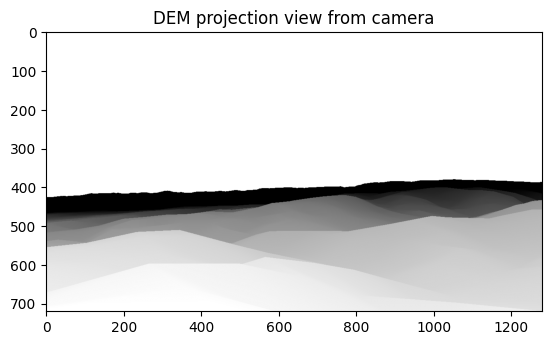

: 

In [ ]:
plt.imshow(255-normalized, cmap='gray')
plt.title("DEM projection view from camera")
plt.show()

: 

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use mps:0
[ WARN:0@64.997] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


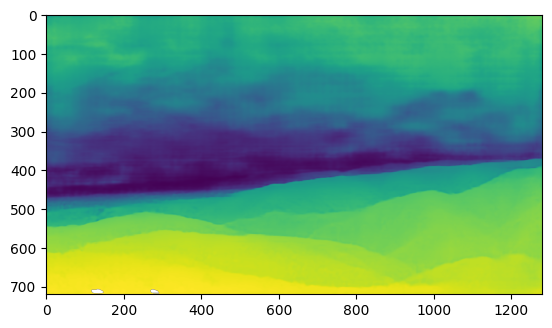

: 

In [ ]:
from transformers import pipeline
from PIL import Image
import requests

# load pipe
pipe = pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Metric-Outdoor-Large-hf")

refcam_img = Image.open(img_file)
depth_pred = pipe(refcam_img)["depth"]

img_depth = np.asarray(depth_pred)

# Invert to make depth increase with distance
mid = (np.nanmin(img_depth) + np.nanmax(img_depth)) / 2
img_depth = 2 * mid - img_depth
img_depth = np.where(img_depth == 255, np.nan, img_depth)
cv2.imwrite("depth.jpg", img_depth)
plt.imshow(img_depth)

: 

: 

: 

: 

Device set to use mps:0


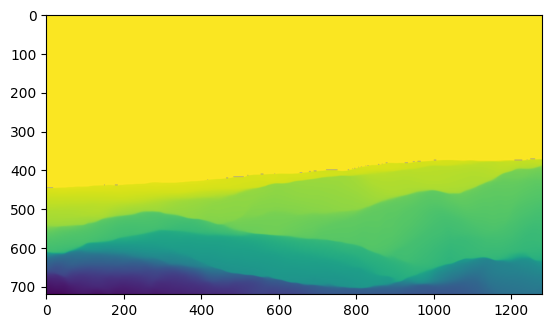

: 

: 

: 

: 

In [20]:
pipe = pipeline(task="depth-estimation", model="LiheYoung/depth-anything-small-hf")

refcam_img = Image.open(img_file)
depth_pred = pipe(refcam_img)["depth"]

img_depth = np.asarray(depth_pred)

# Invert to make depth increase with distance
mid = (np.nanmin(img_depth) + np.nanmax(img_depth)) / 2
img_depth = 2 * mid - img_depth
img_depth = np.where(img_depth == 255, np.nan, img_depth)
plt.imshow(img_depth)

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 